# Player Retention and Churn Modeling
*This notebook analyzes player behavior from a simulated multiplayer game.*

Notebook Author: Ilan Harari <br>
Data Source: https://pypi.org/project/players-behaviors-dataset-generator/#description 

In [1]:
#imports
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import sklearn
print("All libraries are working!")
import os

All libraries are working!


In [2]:
#read in data
df = pd.read_csv('../data/synthetic_player_data.csv')

## Exploratory Analysis

1. Descriptive Statistics
2. Cleaning
3. Preparation for modeling

### Descriptive Stats

In [6]:
df.shape
df.info()
df.head()
df.describe(include='object')

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6772064 entries, 0 to 6772063
Data columns (total 9 columns):
 #   Column       Dtype  
---  ------       -----  
 0   id           object 
 1   cohort_id    object 
 2   player_id    object 
 3   player_type  object 
 4   session_id   object 
 5   event_type   object 
 6   timestamp    object 
 7   stage_id     object 
 8   stage_score  float64
dtypes: float64(1), object(8)
memory usage: 465.0+ MB


,id,cohort_id,player_id,player_type,session_id,event_type,timestamp,stage_id
count,6772064,6772064,6772064,6772064,6772064,6772064,6772064,6454974
unique,6772064,16,37267,3,158545,4,6772010,3227487
top,4884173d44434919b0442a23bce9e582,2727be5761d6401ebed5e0e8e2812a4b,c01f082542684ed082c2b2ba6d1c23eb,churner,e8e8c70f670548a18afa30ed3dfa6b8c,END_STAGE,2025-05-05 11:08:57.507621,4e144fc7-e0ca-4b40-95ec-f5681d36bceb
freq,1,951754,1346,5141962,88,3227487,2,2


In [23]:
df['player_type'].value_counts()

churner     5141962
hardcore    1246322
casual       383780
Name: player_type, dtype: int64

In [26]:
df['event_type'].value_counts(normalize=False)

END_STAGE        3227487
BEGIN_STAGE      3227487
BEGIN_SESSION     158545
END_SESSION       158545
Name: event_type, dtype: int64

### Data Cleaning

1. Check for nulls
2. Check for duplicates
3. Ensure proper types
    1. Dates in datetime format
4. Rename columns for consistency
5. Visualizations, plots

In [31]:
# 1. Null check
df.isnull().sum().sort_values(ascending=False)

stage_score    3544577
stage_id        317090
timestamp            0
event_type           0
session_id           0
player_type          0
player_id            0
cohort_id            0
id                   0
dtype: int64

In [30]:
# Explore null stage score and stage id
print(df[df['stage_score'].isna()]['event_type'].value_counts())
print(df[df['stage_id'].isna()]['event_type'].value_counts())

BEGIN_STAGE      3227487
BEGIN_SESSION     158545
END_SESSION       158545
Name: event_type, dtype: int64
BEGIN_SESSION    158545
END_SESSION      158545
Name: event_type, dtype: int64


In [9]:
#2. Duplicate check
df.duplicated().sum()

0

In [10]:
#3. Fix timestamp type
df['timestamp'] = pd.to_datetime(df['timestamp'])
df['timestamp'].head()

In [82]:
#4. Rename columns
df.columns
df.rename(columns={'id': 'event_id', 'player_type':'player_label', 'cohort_id': 'player_cohort'})

,event_id,player_cohort,player_id,player_label,session_id,event_type,timestamp,stage_id,stage_score,weekday,hour,minute,week
0,0a68f1b2b0954b4cae6b92ed1ef70dbf,2af4a515434c4606836489a579a9f740,ac99c609dc974d4182754b9803a71279,casual,37dfcbf7c2bd487cbc1e06155e419773,BEGIN_SESSION,2025-04-06 12:42:06.694924,NaN,NaN,Sunday,12,42,14
1,4f42ec16fdcd4668b506d1a2709d16f4,2af4a515434c4606836489a579a9f740,ac99c609dc974d4182754b9803a71279,casual,37dfcbf7c2bd487cbc1e06155e419773,BEGIN_STAGE,2025-04-06 12:45:27.012508,7abbefec-6e62-4241-9bde-ac7a6b9723c9,NaN,Sunday,12,45,14
2,661ebc6b1ede47f4b23eb12accbeb329,2af4a515434c4606836489a579a9f740,ac99c609dc974d4182754b9803a71279,casual,37dfcbf7c2bd487cbc1e06155e419773,END_STAGE,2025-04-06 12:46:24.705289,7abbefec-6e62-4241-9bde-ac7a6b9723c9,207.0,Sunday,12,46,14
3,6fab9800706a44648aba9f7126101df0,2af4a515434c4606836489a579a9f740,ac99c609dc974d4182754b9803a71279,casual,37dfcbf7c2bd487cbc1e06155e419773,BEGIN_STAGE,2025-04-06 12:50:04.065869,beb754d3-1ce0-4eca-bcf0-a69d0018af5c,NaN,Sunday,12,50,14
4,b13d415c4f9a4023ac8feeb941e958fd,2af4a515434c4606836489a579a9f740,ac99c609dc974d4182754b9803a71279,casual,37dfcbf7c2bd487cbc1e06155e419773,END_STAGE,2025-04-06 12:50:48.634408,beb754d3-1ce0-4eca-bcf0-a69d0018af5c,841.0,Sunday,12,50,14
...,...,...,...,...,...,...,...,...,...,...,...,...,...
6772059,bc52d89e92b64437aa9099e4e933b5c1,0f05a559fe884707a00fe82bcffc445f,8ba2fdb42e8e44caaf82bc2d655dff4f,hardcore,47a672db0d0d49f8bf1d5ddcfb83e62d,BEGIN_STAGE,2025-05-13 10:04:54.458070,b6e16a3e-a9b1-46de-b75d-84f13888c96e,NaN,Tuesday,10,04,19
6772060,01d39c80b4a54aaba204018b22a37227,0f05a559fe884707a00fe82bcffc445f,8ba2fdb42e8e44caaf82bc2d655dff4f,hardcore,47a672db0d0d49f8bf1d5ddcfb83e62d,END_STAGE,2025-05-13 10:05:56.783558,b6e16a3e-a9b1-46de-b75d-84f13888c96e,1095.0,Tuesday,10,05,19
6772061,6683c53ca54447a693760fcb83bdf063,0f05a559fe884707a00fe82bcffc445f,8ba2fdb42e8e44caaf82bc2d655dff4f,hardcore,47a672db0d0d49f8bf1d5ddcfb83e62d,BEGIN_STAGE,2025-05-13 10:08:13.757034,cc146b54-c384-421f-92c4-04bc5bfe5289,NaN,Tuesday,10,08,19
6772062,959576e6808d4ab695fb79502e0da347,0f05a559fe884707a00fe82bcffc445f,8ba2fdb42e8e44caaf82bc2d655dff4f,hardcore,47a672db0d0d49f8bf1d5ddcfb83e62d,END_STAGE,2025-05-13 10:09:21.779627,cc146b54-c384-421f-92c4-04bc5bfe5289,972.0,Tuesday,10,09,19


#### Visualizations & Plots

In [55]:
# DateTime columns
df['weekday'] = df['timestamp'].dt.strftime('%A')
df['hour'] = df['timestamp'].dt.strftime('%H')
df['minute'] = df['timestamp'].dt.strftime('%M')


Text(0.5, 1.0, 'Count of events by Player Type')

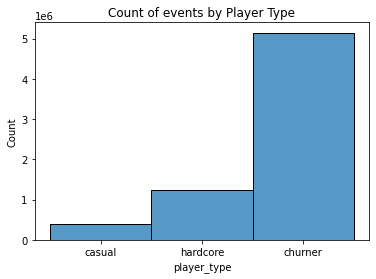

In [58]:
# Class balance for target variable
sns.histplot(data=df, x='player_type')
plt.title("Count of events by Player Type")

Text(0, 0.5, 'Number of Events')

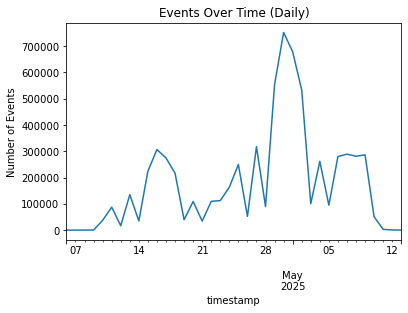

In [40]:
#Events by day
df.set_index('timestamp')['event_type'].resample('D').count().plot()
plt.title("Events Over Time (Daily)")
plt.ylabel("Number of Events")

Text(0, 0.5, 'Number of Events')

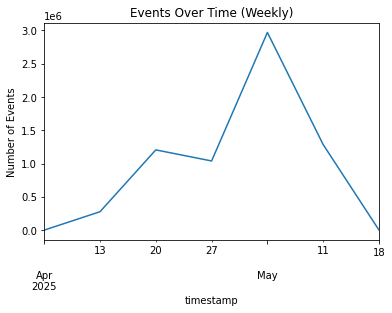

In [50]:
# Events by Week
df.set_index('timestamp')['event_type'].resample('W').count().plot()
plt.title("Events Over Time (Weekly)")
plt.ylabel("Number of Events")

Text(0.5, 0, 'Hour (0 = Midnight)')

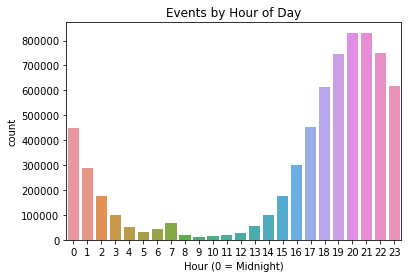

In [67]:
order = list(range(0, 24))
df['hour'] = df['hour'].astype(int)
sns.countplot(data=df, x='hour', order=order, )
plt.title("Events by Hour of Day")
plt.xlabel("Hour (0 = Midnight)")

(array([0, 1, 2, 3, 4, 5, 6]),
 [Text(0, 0, 'Sunday'),
  Text(1, 0, 'Monday'),
  Text(2, 0, 'Tuesday'),
  Text(3, 0, 'Wednesday'),
  Text(4, 0, 'Thursday'),
  Text(5, 0, 'Friday'),
  Text(6, 0, 'Saturday')])

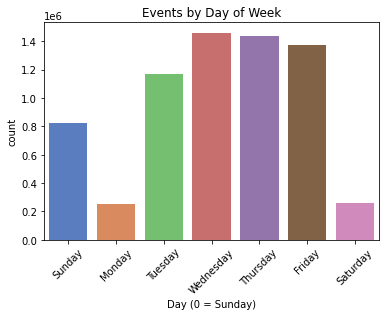

In [78]:
# Events by day of week
order = ['Sunday', 'Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday']
sns.countplot(data=df, x='weekday', palette='muted', order=order)
plt.title("Events by Day of Week")
plt.xlabel("Day (0 = Sunday)")
plt.xticks(rotation=45)

In [81]:
df.columns

Index(['id', 'cohort_id', 'player_id', 'player_type', 'session_id',
       'event_type', 'timestamp', 'stage_id', 'stage_score', 'weekday', 'hour',
       'minute', 'week'],
      dtype='object')

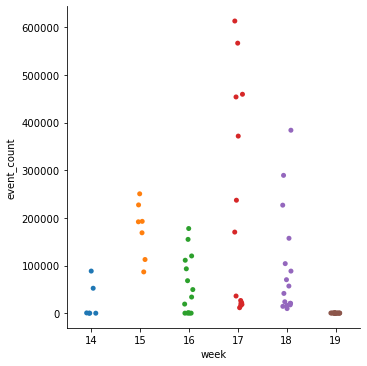

In [86]:
# cohort representation over time
df['week'] = df['timestamp'].dt.strftime('%U')
#make a catplot showing top 3 cohorts for each week of the month

weekly_counts = df.groupby(['week', 'cohort_id'])['player_id'].count().reset_index()

weekly_counts.columns = ['week', 'cohort_id', 'event_count']

top3 = weekly_counts.sort_values(['week', 'event_count'], ascending=[True, False])
top3 = top3.groupby('week').head(3)


In [102]:
top3 = top3.groupby(['week', 'cohort_id']).sum()

In [107]:
top3

event_count
week cohort_id                                    
14   1cd3005aff2b43589f1c760ee744df1f          594
     2af4a515434c4606836489a579a9f740        88445
     e4a6230a095d4b0aa56b5e9582db65d4        52376
15   37c4eb35253f4f47baf7291286d75d86       227302
     a735ce16784745a6adfb3e53ba5627aa       192810
     d071a4dba21b492aaa1847370b3774f9       250608
16   37c4eb35253f4f47baf7291286d75d86       154968
     655e299001484b3a9ef0647869245b21       177737
     d071a4dba21b492aaa1847370b3774f9       120164
17   0f05a559fe884707a00fe82bcffc445f       613363
     2727be5761d6401ebed5e0e8e2812a4b       566885
     ef39512494764aa3b5344628fcbdd6a6       459601
18   0f05a559fe884707a00fe82bcffc445f       289347
     2727be5761d6401ebed5e0e8e2812a4b       384113
     ef39512494764aa3b5344628fcbdd6a6       226807
19   0e286dbab03d493aa25ee3a6440b652c          454
     2727be5761d6401ebed5e0e8e2812a4b          672
     ef39512494764aa3b5344628fcbdd6a6          368

In [109]:

sns.catplot(data=top3, kind='bar', x='week', y='event_count', hue='cohort_id')

#make a catplot showing top 3 cohorts for each day of the week 

#make a catplot showing top 3 cohorts for each hour of the day 


ValueError: Could not interpret input 'week'

### Preparation For Modeling: Feature Creation

In [9]:
unique_players_by_type = df.groupby('player_type')['player_id'].nunique()

In [10]:
print(unique_players_by_type)

player_type
casual       1806
churner     33523
hardcore     1938
Name: player_id, dtype: int64


In [11]:
unique_players_by_cohort = df.groupby('cohort_id')['player_id'].nunique()


In [40]:
#target label
print("Target label raw counts:\n", df['player_type'].value_counts())
print("\nTarget label percentages:\n", df['player_type'].value_counts(normalize=True))

Target label raw counts:
 churner     5141962
hardcore    1246322
casual       383780
Name: player_type, dtype: int64

Target label percentages:
 churner     0.759290
hardcore    0.184039
casual      0.056671
Name: player_type, dtype: float64


In [21]:
df.columns

Index(['id', 'cohort_id', 'player_id', 'player_type', 'session_id',
       'event_type', 'timestamp', 'stage_id', 'stage_score'],
      dtype='object')

In [26]:
# view player type by cohort
type_by_cohort = df.groupby(['cohort_id', 'player_type'])['session_id'].count()


In [27]:
type_by_cohort

cohort_id                         player_type
0e286dbab03d493aa25ee3a6440b652c  casual          26488
                                  churner        364822
                                  hardcore        86012
0f05a559fe884707a00fe82bcffc445f  casual          43994
                                  churner        746120
                                  hardcore       112950
1cd3005aff2b43589f1c760ee744df1f  casual          17282
                                  churner        161424
                                  hardcore        75084
21dd6ddb1b4c4f8fa5302dea61ccd18d  casual          29682
                                  churner        482054
                                  hardcore        99876
21e714cceafa41d481661766e0253bca  casual           1646
                                  churner         52620
                                  hardcore         2948
2727be5761d6401ebed5e0e8e2812a4b  casual          48182
                                  churner        771854
  

In [28]:
pivot = df.pivot_table(
    index='cohort_id',
    columns='player_type',
    values='player_id',
    aggfunc='nunique',   # Or 'count' if each row = 1 player
    fill_value=0         # Optional: replace NaNs with 0s
)

In [29]:
pivot

player_type,casual,churner,hardcore
cohort_id,,,
0e286dbab03d493aa25ee3a6440b652c,140,2707,153
0f05a559fe884707a00fe82bcffc445f,216,4072,212
1cd3005aff2b43589f1c760ee744df1f,67,1187,79
21dd6ddb1b4c4f8fa5302dea61ccd18d,165,3155,180
21e714cceafa41d481661766e0253bca,44,1187,51
2727be5761d6401ebed5e0e8e2812a4b,250,4475,275
2af4a515434c4606836489a579a9f740,49,905,46
37c4eb35253f4f47baf7291286d75d86,95,1802,103
3dc8a33a516840afb5f993509dc32da8,87,1491,88
